## 0. Setup

In [50]:
# INDIA_PROJECTED_CRS = "24378"

In [51]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
# general
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm.notebook import tqdm

# for plotting and coloring
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import matplotlib.cm

# for handling S2 cells and downloading VIDA data
import boto3
from s2cell.s2cell import lat_lon_to_cell_id
import s2sphere
from shapely.geometry import Polygon

gpd.options.io_engine = "pyogrio"

In [53]:
from gridsample.utils import create_ids, create_gmap_links, save_shapefiles
# from gridsample.mapping import create_interactive_map

In [54]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "01. Raw Data"
CLEANED_DATA_DIR = DATA_DIR / "02. Intermediate Outputs"
OUTPUT_DATA_DIR = DATA_DIR / "03. Final Outputs"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [55]:
def generate_colormap(N):
    arr = np.arange(N) / N
    N_up = int(math.ceil(N / 7) * 7)
    arr.resize(N_up)
    arr = arr.reshape(7, N_up // 7).T.reshape(-1)
    ret = matplotlib.cm.hsv(arr)
    n = ret[:, 3].size
    a = n // 2
    b = n - a

    # Create arrays of exactly matching sizes
    for i in range(3):
        ret[0:a, i] *= np.linspace(0.2, 1, a)
    ret[a:, 3] *= np.linspace(1, 0.3, b)

    return ret[:N]  # Return only the requested number of colors

## 1. Load MapSolve boundaries

In [56]:
# get all filepaths that end in `gpkg` inside the RAW_DATA_DIR / 0.1. MapSolve Boundaries
boundaries_dir = RAW_DATA_DIR / "01. MapSolve Boundaries"
gpkg_files_all = list(boundaries_dir.glob("**/*.gpkg"))
gpkg_files_all = [f for f in gpkg_files_all if f.is_file()]
# # drop any with the word "Sub-District" in the filename
# gpkg_files_VTW = [f for f in gpkg_files_all if "Sub-District" not in f.name]
# load all shapes into one gdf
gdf_list = []
for filepath in gpkg_files_all:
    gdf_list.append(gpd.read_file(filepath))
gdf = pd.concat(gdf_list, ignore_index=True).to_crs(4326)

<Axes: >

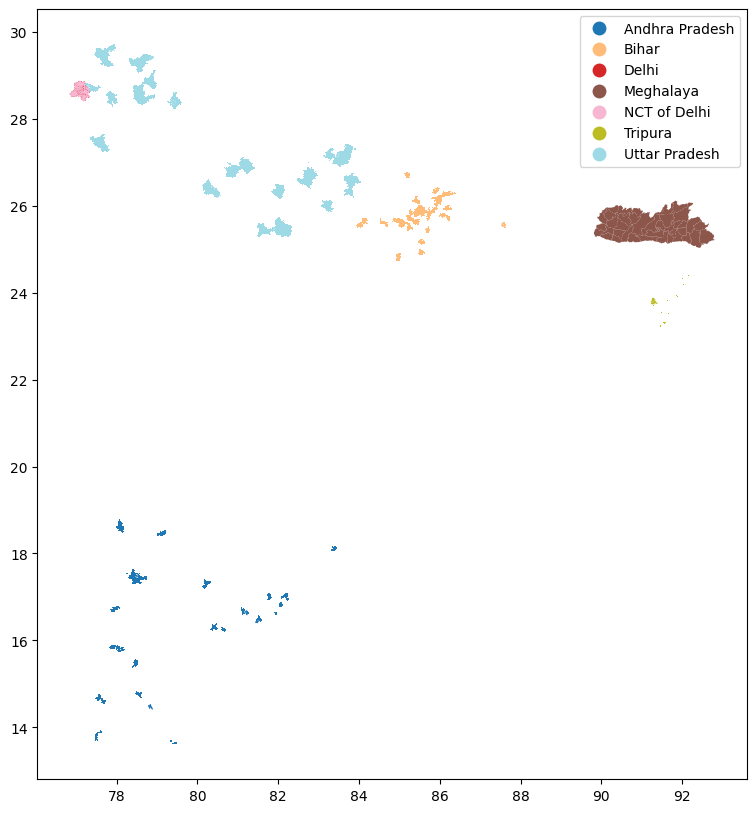

In [57]:
gdf.plot(column="State_N", legend=True, figsize=(10, 10), cmap="tab20")

In [58]:
# boundaries_gdf = gpd.read_file(RAW_DATA_DIR / "01. MapSolve Boundaries/State_C_7/State_C_7.gpkg")
# boundaries_gdf = boundaries_gdf.to_crs(4326)

# boundaries_gdf.plot(
#     column="PCA_ID",
#     figsize=(6, 6),
#     cmap=ListedColormap(generate_colormap(len(boundaries_gdf))),
#     edgecolor="black",
# )
# # create_interactive_map(boundaries_gdf, point_id_col="PCA_ID")

## 2. Load sampled wards data

In [59]:
# load the merged wards data
sample_df = pd.read_csv(
    CLEANED_DATA_DIR
    / "00. Merge and Quality Checks"
    / "Merged Wards with Quality Checks.csv"
)

## 3. Filter MapSolve boundaries to sampled areas

### 3.1 Rename and clean both datasets

In [60]:
rename_dict = {
    "UID": "UID",
    "PCA_ID": "PCA_ID",
    "State_C": "State Code",
    "State_N": "State Name",
    "Dist_C": "District Code",
    "Dist_N": "District Name",
    "SubDist_C": "Subdistrict Code",
    "SubDist_N": "Subdistrict Name",
    "TV_C": "TV Code",
    "TV_N": "TV Name",
    "Ward_C": "Ward Code",
    "TOT_P": "Total Population",
}

gdf = gdf.rename(columns=rename_dict)

In [61]:
rename_dict = {
    "State": "State Code",
    "State_Name": "State Name",
    "District": "District Code",
    "District_Name": "District Name",
    "Subdistrict": "Subdistrict Code",
    "Subd_Name": "Subdistrict Name",
    "TownVillage": "TV Code",
    "UrbanWardVillage": "Ward Code",
    "WardVillage_Name": "Ward/Village Name",
    "TRU": "Urban/Rural",
    "WardVillage_Pop": "Ward Population",
    "Subd_Pop": "Subdistrict Population",
    "State_Pop": "State Population",
    "WardVillageID": "Complete ID",
}
sample_df = sample_df.rename(columns=rename_dict)

# make State Name heading case instead of all caps
sample_df["State Name"] = sample_df["State Name"].str.title()
sample_df.loc[sample_df["State Name"] == "Nct Of Delhi", "State Name"] = "NCT of Delhi"

In [62]:
# make relevant codes into floats for both datasets
code_columns = [
    "State Code",
    "District Code",
    "Subdistrict Code",
    "TV Code",
    "Ward Code",
]
for col in code_columns:
    sample_df[col] = sample_df[col].astype(float)
    gdf[col] = gdf[col].astype(float)

### 3.2 Subset sample data to only given states

In [63]:
given_states_list = list(gdf["State Code"].unique())
given_states_list.append(
    90.0
)  # manually add 90 for the Telangana vs Andhra Pradesh discrepency
given_states_list

[28.0, 17.0, 10.0, 16.0, 9.0, 7.0, 90.0]

In [64]:
given_states_sample_df = sample_df[
    sample_df["State Code"].isin(given_states_list)
].copy()

In [65]:
given_states_sample_df[given_states_sample_df["PSU Type"] == "none"]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,Urban/Rural,...,Source Sheet,State Shared by MapSolve,State Changed,PCA_ID,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,Ward Count
289,9.0,Uttar Pradesh,157.0,Lucknow,821.0,Lucknow,143361.0,0.0,Raniya Mau,Rural,...,Panel,True,No,143361-0,False,False,False,BAD - No boundary(s) given,none,0
304,9.0,Uttar Pradesh,174.0,Kaushambi,887.0,Chail,160687.0,0.0,Hasanpur,Rural,...,Panel,True,No,160687-0,False,False,False,BAD - No boundary(s) given,none,0
366,10.0,Bihar,220.0,Vaishali,1281.0,Desri,235994.0,0.0,Jahangirpur Sham,Rural,...,IFS,True,No,235994-0,False,False,False,BAD - No boundary(s) given,none,0
373,10.0,Bihar,221.0,Samastipur,1300.0,Rosera,237167.0,0.0,Jahangirpur,Rural,...,Both IFS and Panel,True,No,237167-0,False,False,False,BAD - No boundary(s) given,none,0
1011,90.0,Telangana,537.0,Rangareddy,4518.0,Qutubullapur,802918.0,157.0,Mallampet (OG) WARD NO.-0157 (Rural MDDS CODE:...,Urban,...,IFS,True,Previously Andhra Pradesh,802918-157,False,False,False,BAD - No boundary(s) given,none,0


### 3.3 Drop unnecessary rows 

#### Drop rows with no MapSolve shapes

In [66]:
filtered_df = given_states_sample_df[given_states_sample_df["PSU Type"] != "none"]

In [67]:
# check bad rows, leave as is though
filtered_df[filtered_df["Delivery State"].str.contains("BAD")]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,Urban/Rural,...,Source Sheet,State Shared by MapSolve,State Changed,PCA_ID,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,Ward Count
381,10.0,Bihar,230.0,Patna,1400.0,Patna Rural,801373.0,3.0,Patna (M Corp.) WARD NO.-0003,Urban,...,IFS,True,No,801373-3,False,True,False,BAD - Town/Village boundary given but Ward bou...,town_village,1
811,28.0,Andhra Pradesh,548.0,Guntur,5078.0,Tenali,802982.0,1.0,Tenali (M) WARD NO.-0001,Urban,...,Panel,True,No,802982-1,False,True,False,BAD - Town/Village boundary given but Ward bou...,town_village,1


#### Drop dupilcate rows if PSU is TV or Subdistrict

In [68]:
filtered_df = filtered_df[
    # if the PSU Type is "town_village", then drop any duplicated rows with the same TV Code
    ~(
        (filtered_df["PSU Type"] == "town_village")
        & (filtered_df.duplicated(subset=["TV Code"], keep="first"))
    )
    # similar for subdistrict
    & ~(
        (filtered_df["PSU Type"] == "subdistrict")
        & (filtered_df.duplicated(subset=["Subdistrict Code"], keep="first"))
    )
]

filtered_df.value_counts("PSU Type")

PSU Type
ward            146
town_village    144
subdistrict      15
Name: count, dtype: int64

#### Duplicated wards

In [69]:
filtered_df[filtered_df["PCA_ID"].duplicated(keep=False)]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,Urban/Rural,...,Source Sheet,State Shared by MapSolve,State Changed,PCA_ID,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,Ward Count
135,7.0,NCT of Delhi,90.0,North West,431.0,Saraswati Vihar,800441.0,59.0,DMC (U) (Part) WARD NO.-0059,Urban,...,IFS,True,No,800441-59,True,False,True,GOOD - Ward boundary given as expected,ward,1
187,7.0,NCT of Delhi,96.0,West,448.0,Patel Nagar,800441.0,99.0,DMC (U) (Part) WARD NO.-0099,Urban,...,IFS,True,No,800441-99,True,False,True,GOOD - Ward boundary given as expected,ward,1
201,7.0,NCT of Delhi,96.0,West,450.0,Punjabi Bagh,800441.0,59.0,DMC (U) (Part) WARD NO.-0059,Urban,...,Both IFS and Panel,True,No,800441-59,True,False,True,GOOD - Ward boundary given as expected,ward,1
202,7.0,NCT of Delhi,96.0,West,450.0,Punjabi Bagh,800441.0,99.0,DMC (U) (Part) WARD NO.-0099,Urban,...,IFS,True,No,800441-99,True,False,True,GOOD - Ward boundary given as expected,ward,1
210,7.0,NCT of Delhi,97.0,South West,451.0,Najafgarh,800441.0,136.0,DMC (U) (Part) WARD NO.-0136,Urban,...,Panel,True,No,800441-136,True,False,True,GOOD - Ward boundary given as expected,ward,1
219,7.0,NCT of Delhi,97.0,South West,453.0,Vasant Vihar,800441.0,136.0,DMC (U) (Part) WARD NO.-0136,Urban,...,IFS,True,No,800441-136,True,False,True,GOOD - Ward boundary given as expected,ward,1
237,7.0,NCT of Delhi,98.0,South,455.0,Defence Colony,800441.0,208.0,DMC (U) (Part) WARD NO.-0208,Urban,...,Panel,True,No,800441-208,True,False,True,GOOD - Ward boundary given as expected,ward,1
244,7.0,NCT of Delhi,98.0,South,456.0,Kalkaji,800441.0,208.0,DMC (U) (Part) WARD NO.-0208,Urban,...,IFS,True,No,800441-208,True,False,True,GOOD - Ward boundary given as expected,ward,1


In [70]:
print(f"Number of rows before dropping PCA_ID duplicates: {len(filtered_df)}")
print(
    f"Number of rows after dropping PCA_ID duplicates: {len(filtered_df.drop_duplicates(subset=['PCA_ID'], keep='first'))}"
)

Number of rows before dropping PCA_ID duplicates: 305
Number of rows after dropping PCA_ID duplicates: 301


In [71]:
filtered_df = filtered_df.drop_duplicates(subset=["PCA_ID"], keep="first")

## 4. Merge shapes at the respective PSU level

### Wards

In [72]:
# PCA IDs to match (TVCode-WardCode)
pca_ids_to_match = filtered_df.loc[filtered_df["PSU Type"] == "ward", "PCA_ID"].unique()
len(pca_ids_to_match)

142

In [73]:
wards_gdf = gpd.GeoDataFrame(
    filtered_df[filtered_df["PSU Type"] == "ward"].merge(
        gdf[gdf["PCA_ID"].isin(pca_ids_to_match)],
        on=["PCA_ID"],
        how="left",
        suffixes=("", "_MapSolve"),
    ),
    geometry="geometry",
)
wards_gdf.shape

(142, 39)

### Town/Village

In [74]:
# TV codes to match
tv_codes_to_match = filtered_df.loc[
    filtered_df["PSU Type"] == "town_village", "TV Code"
].unique()
len(tv_codes_to_match)

144

In [75]:
tv_gdf = gpd.GeoDataFrame(
    filtered_df[filtered_df["PSU Type"] == "town_village"].merge(
        gdf[gdf["TV Code"].isin(tv_codes_to_match) & gdf["Ward Code"].isna()],
        on=["TV Code"],
        how="left",
        suffixes=("", "_MapSolve"),
    )
)
tv_gdf.shape

(144, 39)

In [76]:
# cut out the ward geometries from the TV geometries so we don't double sample those areas
trimmed_tv_geoms = tv_gdf.difference(wards_gdf.geometry.unary_union)
trimmed_tv_gdf = gpd.GeoDataFrame(
    tv_gdf.drop(columns="geometry").assign(geometry=trimmed_tv_geoms),
    crs=tv_gdf.crs,
)

### Subdistrict

In [77]:
# subdistrict codes to match
subdistrict_codes_to_match = filtered_df.loc[
    filtered_df["PSU Type"] == "subdistrict", "Subdistrict Code"
].unique()
len(subdistrict_codes_to_match)

15

In [78]:
subdistrict_gdf = gpd.GeoDataFrame(
    filtered_df[filtered_df["PSU Type"] == "subdistrict"].merge(
        gdf[
            gdf["Subdistrict Code"].isin(subdistrict_codes_to_match)
            & (gdf["TV Code"].isna())
            & (gdf["Ward Code"].isna())
        ],
        on=["Subdistrict Code"],
        how="left",
        suffixes=("", "_MapSolve"),
    )
)
subdistrict_gdf

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,Urban/Rural,...,State Code_MapSolve,State Name_MapSolve,District Code_MapSolve,District Name_MapSolve,Subdistrict Name_MapSolve,TV Code_MapSolve,TV Name,Ward Code_MapSolve,Total Population,geometry
0,7.0,NCT of Delhi,90.0,North West,430.0,Narela,63910.0,3.0,Ali Pur (CT) WARD NO.-0003,Urban,...,7.0,NCT of Delhi,90.0,North West,Narela,NaN,NaN,NaN,641174.0,"MULTIPOLYGON (((77.16061 28.75067, 77.16034 28..."
1,7.0,NCT of Delhi,90.0,North West,431.0,Saraswati Vihar,63936.0,28.0,Qutab Garh (CT) WARD NO.-0028,Urban,...,7.0,NCT of Delhi,90.0,North West,Saraswati Vihar (Kanjhawala),NaN,NaN,NaN,2205605.0,"MULTIPOLYGON (((77.08219 28.72846, 77.08219 28..."
2,7.0,NCT of Delhi,90.0,North West,432.0,Model Town,63950.0,5.0,Bhalswa Jahangir Pur (CT) WARD NO.-0005,Urban,...,7.0,NCT of Delhi,90.0,North West,Model Town,NaN,NaN,NaN,595810.0,"MULTIPOLYGON (((77.19565 28.72869, 77.19565 28..."
3,7.0,NCT of Delhi,91.0,North,433.0,Civil Lines,63951.0,0.0,Salem Pur Majra Burari,Rural,...,7.0,NCT of Delhi,91.0,North,Civil Lines,NaN,NaN,NaN,670870.0,"MULTIPOLYGON (((77.23877 28.73011, 77.23877 28..."
4,7.0,NCT of Delhi,92.0,North East,436.0,Seelam Pur,63968.0,272.0,Sadat Pur Gujran (CT) WARD NO.-0272,Urban,...,7.0,NCT of Delhi,92.0,North East,Seelam Pur,NaN,NaN,NaN,1357252.0,"MULTIPOLYGON (((77.27757 28.69773, 77.27757 28..."
5,7.0,NCT of Delhi,92.0,North East,437.0,Shahdara,63980.0,260.0,Babar Pur (CT) WARD NO.-0260,Urban,...,7.0,NCT of Delhi,92.0,North East,Shahdara,NaN,NaN,NaN,322931.0,"MULTIPOLYGON (((77.27973 28.68189, 77.27973 28..."
6,7.0,NCT of Delhi,93.0,East,441.0,Preet Vihar,63985.0,220.0,Gharonda Neemka Bangar alias Patpar Ganj (CT) ...,Urban,...,7.0,NCT of Delhi,93.0,East,Preet Vihar,NaN,NaN,NaN,1062568.0,"MULTIPOLYGON (((77.30344 28.58420, 77.30344 28..."
7,7.0,NCT of Delhi,96.0,West,448.0,Patel Nagar,63991.0,122.0,Hastsal (CT) WARD NO.-0122,Urban,...,7.0,NCT of Delhi,96.0,West,Patel Nagar,NaN,NaN,NaN,1262158.0,"MULTIPOLYGON (((77.03341 28.64619, 77.03368 28..."
8,7.0,NCT of Delhi,96.0,West,450.0,Punjabi Bagh,63999.0,43.0,Nangloi Jat (CT) WARD NO.-0043,Urban,...,7.0,NCT of Delhi,96.0,West,Punjabi Bagh,NaN,NaN,NaN,793033.0,"MULTIPOLYGON (((77.03368 28.64642, 77.03368 28..."
9,7.0,NCT of Delhi,97.0,South West,451.0,Najafgarh,64004.0,0.0,Dichaon Kalan,Rural,...,7.0,NCT of Delhi,97.0,South West,Najafgarh,NaN,NaN,NaN,1221476.0,"MULTIPOLYGON (((76.88573 28.50253, 76.88519 28..."


In [79]:
# cut out the TV and Ward geometries from the subdistrict geometries so we don't double sample those areas
combined_tv_and_ward_union_shape = wards_gdf.geometry.unary_union.union(
    trimmed_tv_gdf.geometry.unary_union
)
trimmed_subdistrict_geoms = subdistrict_gdf.difference(combined_tv_and_ward_union_shape)
trimmed_subdistrict_gdf = gpd.GeoDataFrame(
    subdistrict_gdf.drop(columns="geometry").assign(geometry=trimmed_subdistrict_geoms),
    crs=subdistrict_gdf.crs,
)

### Combine

In [80]:
# combine all three GeoDataFrames into one
combined_gdf = gpd.GeoDataFrame(
    pd.concat(
        [
            wards_gdf,
            trimmed_tv_gdf,
            trimmed_subdistrict_gdf,
        ],
        ignore_index=True,
    )
)
combined_gdf = combined_gdf.sort_values(
    by=["State Code", "District Code", "Subdistrict Code", "TV Code", "Ward Code"]
).reset_index(drop=True)

<Axes: >

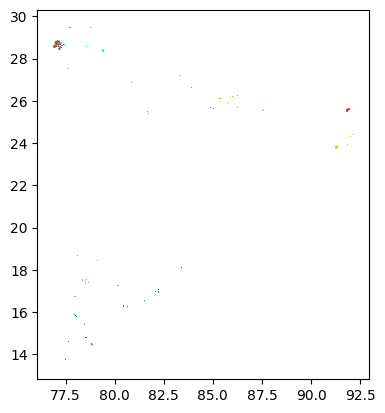

In [81]:
combined_gdf.plot(column="State Name")

#### Add unique overall ID column

In [ ]:
# add an ID column that is unique across all rows. It should be WARD_{PCA_ID} if the PSU Type is "ward", TV_{TV Code} if the PSU Type is "town_village", and SUBDISTRICT_{Subdistrict Code} if the PSU Type is "subdistrict"
combined_gdf["PSU_ID"] = combined_gdf.apply(
    lambda row: f"WARD_{row['PCA_ID']}"
    if row["PSU Type"] == "ward"
    else f"TV_{row['TV Code']}"
    if row["PSU Type"] == "town_village"
    else f"SUBDISTRICT_{row['Subdistrict Code']}",
    axis=1,
).astype(str)

In [ ]:
len(combined_gdf) == combined_gdf["PSU_ID"].nunique()

True

In [84]:
combined_gdf["UID"] = combined_gdf["UID"].astype(str)

In [85]:
save_shapefiles(
    combined_gdf,
    OUTPUT_DATA_DIR / "Sampled PSUs",
    "six_state_sample_june_10",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Ali Pur (CT) WARD NO.-0003' of field six_state_sample_june_10.TV Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Urban' of field six_state_sample_june_10.Ward Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Invalid value '63910-3' for boolean field six_state_sample_june_10.State Shared by MapSolve. Assuming it to be false.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Invalid value 'GOOD - Subdistrict boundary given as expected' for boolean field six_state_sample_june_10.TV Boundary Given. Assuming it to be false.
  ogr_write(


## 5. Download rooftops

### Functions

#### S2 cell shapes

In [86]:
def s2_cell_id_to_shape(s2_cell_id):
    """
    Convert an S2 cell ID to a shapely polygon.

    Parameters:
    - s2_cell_id (int): The S2 cell ID

    Returns:
    - shapely.geometry.Polygon: Polygon representing the S2 cell
    """
    # Convert string to int if necessary
    if isinstance(s2_cell_id, str):
        s2_cell_id = int(s2_cell_id)

    # Create an S2 cell from the ID
    cell = s2sphere.CellId(s2_cell_id)
    cell = s2sphere.Cell(cell)

    # Extract the vertices of the cell
    vertices = []
    for i in range(4):
        vertex = cell.get_vertex(i)
        lat_lng = s2sphere.LatLng.from_point(vertex)
        vertices.append((lat_lng.lng().degrees, lat_lng.lat().degrees))

    # Close the polygon by repeating the first vertex
    vertices.append(vertices[0])

    # Create a shapely polygon
    return Polygon(vertices)


def s2_cell_ids_to_shapes_gdf(s2_cell_ids):
    """
    Convert a list of S2 cell IDs to a GeoDataFrame with polygon geometries.

    Parameters:
    - s2_cell_ids (list): List of S2 cell IDs

    Returns:
    - geopandas.GeoDataFrame: GeoDataFrame with S2 cells as polygons
    """
    geometries = []
    for s2_id in s2_cell_ids:
        polygon = s2_cell_id_to_shape(s2_id)
        geometries.append(polygon)

    return gpd.GeoDataFrame(
        {"s2_cell_id": s2_cell_ids, "geometry": geometries}, crs="EPSG:4326"
    )

#### Find IDs of overlapping S2 cells

In [87]:
def get_s2_cell_ids_from_points(points, level=6) -> list[int]:
    """
    Get S2 cell IDs for the given points at the specified level.
    """
    # check if crs is set to WGS84 (EPSG:4326)
    if points.crs is None or points.crs.to_string() != "EPSG:4326":
        raise ValueError("Points GeoDataFrame must be in WGS84 (EPSG:4326) CRS.")

    # convert points to S2 cell IDs
    s2_cell_id_list = points.geometry.apply(
        lambda geom: lat_lon_to_cell_id(geom.y, geom.x, level)
    )
    s2_cell_ids = s2_cell_id_list.unique().tolist()

    return s2_cell_ids


def get_s2_cell_ids(gdf, level=6) -> list[int]:
    """
    Get S2 cell IDs of S2 cells that overlap the given GeoDataFrame at the specified level.

    Iteratively checks if any area is not covered by an S2 cell and continues until all areas are covered.

    Parameters:
    - gdf: GeoDataFrame in WGS84 (EPSG:4326) CRS
    - level: int

    Returns:
    - list[int]: List of S2 cell IDs
    """

    # check if crs is set to WGS84 (EPSG:4326)
    if gdf.crs is None or gdf.crs.to_string() != "EPSG:4326":
        raise ValueError("GeoDataFrame must be in WGS84 (EPSG:4326) CRS.")

    # generate initial S2 cell IDs from the GeoDataFrame centroids
    points = gdf.geometry.centroid.to_frame(name="geometry")
    s2_cell_ids = get_s2_cell_ids_from_points(points, level=level)

    # get initial S2 cell shapes and check for full coverage
    s2_cell_shapes = s2_cell_ids_to_shapes_gdf(s2_cell_ids)
    leftover_shapes = gdf.difference(s2_cell_shapes.unary_union)
    leftover_shapes = leftover_shapes[~leftover_shapes.is_empty]

    print(f"Shapes with spillover after round 1: {len(leftover_shapes)}")

    step = 2
    while len(leftover_shapes) > 0:
        # get new s2 cell IDs from the leftover shapes
        points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")
        s2_cell_ids_new = get_s2_cell_ids_from_points(points_new, level=level)

        # get new s2 cell shapes
        s2_cell_shapes = s2_cell_ids_to_shapes_gdf(s2_cell_ids_new)
        leftover_shapes = leftover_shapes.difference(s2_cell_shapes.unary_union)
        leftover_shapes = leftover_shapes[~leftover_shapes.is_empty]

        # add new s2 cell IDs to the existing list
        s2_cell_ids = s2_cell_ids + s2_cell_ids_new

        print(f"Shapes with spillover after round {step}: {len(leftover_shapes)}")
        step += 1

    return s2_cell_ids

#### Auto-download rooftop data by S2 cell ID

In [88]:
def download_VIDA_rooftops_data_by_s2_single(
    s2_cell_id: int, country_iso_code: str, target_data_dir: Path
) -> None:
    """
    Download S2 rooftops data for a given S2 cell ID from the VIDA S3 bucket. URL:
    https://beta.source.coop/vida/google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/
    """

    s2_rooftops_path = target_data_dir / f"{s2_cell_id}.parquet"

    if s2_rooftops_path.exists():
        print(f"File {s2_cell_id} already exists.")
    else:
        print(f"Downloading file for S2 cell ID: {s2_cell_id}")
        s2_rooftops_path.parent.mkdir(parents=True, exist_ok=True)
        s3 = boto3.client("s3", endpoint_url="https://data.source.coop")
        try:
            s3.download_file(
                "vida",
                f"google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso={country_iso_code}/{s2_cell_id}.parquet",
                str(s2_rooftops_path),
            )
            print(f"File {s2_cell_id} downloaded.")
        except Exception as e:
            raise RuntimeError(
                f"Failed to download file for S2 cell ID {s2_cell_id}: {e}"
            )


def download_VIDA_rooftops_data_by_s2(
    s2_cell_ids: list[int], country_iso_code: str, target_data_dir: Path
) -> None:
    """
    Download S2 rooftops data for multiple S2 cell IDs

    Parameters:
    - s2_cell_ids: list of S2 cell IDs
    - country_iso_code: ISO code of the country (e.g., "IND" for India)
    - target_data_dir: directory to save the downloaded data
    """

    for s2_cell_id in tqdm(s2_cell_ids, desc="Downloading rooftops by S2 cell"):
        download_VIDA_rooftops_data_by_s2_single(
            s2_cell_id, country_iso_code, target_data_dir
        )

### Run

#### Identify S2 cell IDs

In [89]:
s2_cell_ids = get_s2_cell_ids(combined_gdf)  # get_s2_cell_ids(boundaries_gdf)
len(s2_cell_ids)

Shapes with spillover after round 1: 4
Shapes with spillover after round 2: 0


/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_41929/1927699269.py:37: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_41929/1927699269.py:50: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


33

#### Check if identified cells cover all areas of interest

In [90]:
s2_cells_gdf = s2_cell_ids_to_shapes_gdf(s2_cell_ids)

In [91]:
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = combined_gdf.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")

0.0 square degrees area not covered by an S2 cell


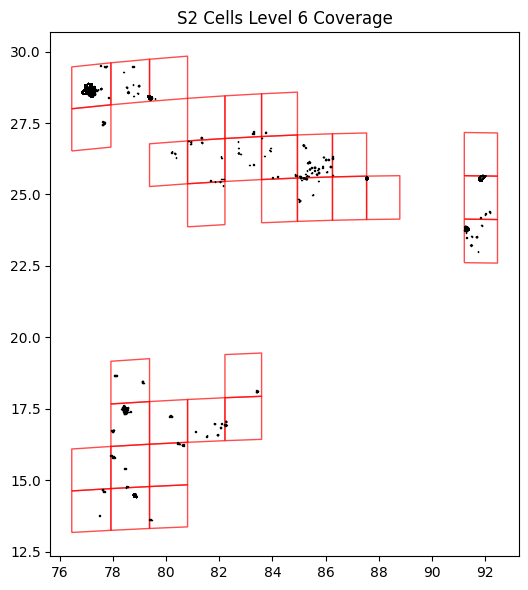

In [92]:
# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
combined_gdf.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()

In [93]:
s2_cells_gdf_w_state = (
    s2_cells_gdf.sjoin(
        combined_gdf[["State Name", "geometry"]], how="inner", predicate="intersects"
    )
    .drop(columns="index_right")
    .drop_duplicates()
)

#### Download the S2 cells

In [94]:
download_VIDA_rooftops_data_by_s2(s2_cell_ids, "IND", RAW_DATA_DIR / "02. Rooftop Data")

File 4110942034859130880 already exists.
File 4110379084905709568 already exists.
File 4139652482483617792 already exists.
File 4152600331412307968 already exists.
File 4150911481552044032 already exists.
File 4150348531598622720 already exists.
File 4151474431505465344 already exists.
File 4144719032064409600 already exists.
File 4148096731784937472 already exists.
File 4149222631691780096 already exists.
File 4149785581645201408 already exists.
File 4148659681738358784 already exists.
File 4173992429642317824 already exists.
File 4174555379595739136 already exists.
File 4177933079316267008 already exists.
File 4175681279502581760 already exists.
File 4146970831878094848 already exists.
File 3986530095153020928 already exists.
File 3985967145199599616 already exists.
File 4195947477825748992 already exists.
File 4194821577918906368 already exists.
File 4195384527872327680 already exists.
File 4200451077453119488 already exists.
File 4302345019022376960 already exists.
File 43017820690

## 6. Load rooftops and match to areas

In [95]:
def get_matched_rooftop_centroids_from_s2_file(
    s2_cell_id: int, boundaries_gdf: gpd.GeoDataFrame
) -> gpd.GeoDataFrame:
    """
    Get rooftops from the S2 cell file that match the boundaries:
    1. loads the rooftops data for the specified S2 cell ID
    2. filters the rooftops to only those that intersect with the boundaries
    3. returns a GeoDataFrame of the matched rooftops centroids with unique IDs

    Parameters:
    - s2_cell_id (int): The S2 cell ID to filter rooftops for.
    - boundaries_gdf (gpd.GeoDataFrame): The GeoDataFrame containing the boundaries.
    """

    # load the rooftops data for the S2 cell
    s2_rooftops_path = RAW_DATA_DIR / "02. Rooftop Data" / f"{s2_cell_id}.parquet"
    s2_rooftops_gdf = gpd.read_parquet(s2_rooftops_path)

    # replace polygons with just the centroid of the rooftops
    s2_rooftop_centroids_gdf = s2_rooftops_gdf.set_geometry(
        s2_rooftops_gdf.geometry.centroid
    )

    # filter the boundaries dataset to only the shapes that overlap the S2 cell
    s2_cell_polygon = s2_cell_id_to_shape(s2_cell_id)
    boundaries_gdf_s2_overlap = boundaries_gdf[
        boundaries_gdf.intersects(s2_cell_polygon)
    ]

    # perform a spatial join to filter and add area metadata to the rooftops
    matched_rooftop_centroids_gdf = gpd.sjoin(
        s2_rooftop_centroids_gdf,
        boundaries_gdf_s2_overlap,
        how="inner",
        predicate="within",
    ).drop(columns=["index_right"])

    # add IDs to each rooftop
    matched_rooftop_centroids_gdf["s2_rooftop_id"] = create_ids(
        len(matched_rooftop_centroids_gdf), f"S2_{s2_cell_id}_ROOFTOP_"
    )

    return matched_rooftop_centroids_gdf

In [96]:
state_names = combined_gdf["State Name"].sort_values().unique()

In [97]:
state_names

array(['Andhra Pradesh', 'Bihar', 'Meghalaya', 'NCT of Delhi',
       'Telangana', 'Tripura', 'Uttar Pradesh'], dtype=object)

In [98]:
for state_name in tqdm(state_names):
    print(f"Processing state: {state_name}")

    # Filter the s2 cells and rooftops gdf to the current state
    s2_cell_ids = set(
        s2_cells_gdf_w_state[s2_cells_gdf_w_state["State Name"] == state_name][
            "s2_cell_id"
        ]
    )
    print(
        f"Number of S2 cells that overlap our shapes in {state_name}: {len(s2_cell_ids)}"
    )
    gdf_subset = combined_gdf[combined_gdf["State Name"] == state_name]

    # Get matched rooftops for each S2 cell in the state
    matched_rooftop_centroids_gdf_list = []
    for s2_cell_id in tqdm(s2_cell_ids):
        matched_rooftop_centroids_gdf = get_matched_rooftop_centroids_from_s2_file(
            s2_cell_id, gdf_subset
        )
        matched_rooftop_centroids_gdf_list.append(matched_rooftop_centroids_gdf)
    matched_rooftop_centroids_gdf = pd.concat(
        matched_rooftop_centroids_gdf_list, ignore_index=True
    )
    matched_rooftop_centroids_gdf["State Name"] = state_name

    # Save the matched rooftops data
    save_shapefiles(
        matched_rooftop_centroids_gdf,
        CLEANED_DATA_DIR / "01. Matched Rooftop Data" / f"{state_name}",
        "matched_rooftops",
        ["parquet"],
    )

  0%|          | 0/7 [00:00<?, ?it/s]

Processing state: Andhra Pradesh
Number of S2 cells that overlap our shapes in Andhra Pradesh: 10


  0%|          | 0/10 [00:00<?, ?it/s]

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_41929/207331629.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_41929/207331629.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_41929/207331629.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_41929/207331629.py:21: UserWarni

Processing state: Bihar
Number of S2 cells that overlap our shapes in Bihar: 7


...

  0%|          | 0/2 [00:00<?, ?it/s]

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_41929/207331629.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_41929/207331629.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid


Processing state: Uttar Pradesh
Number of S2 cells that overlap our shapes in Uttar Pradesh: 12


  0%|          | 0/12 [00:00<?, ?it/s]

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_41929/207331629.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_41929/207331629.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_41929/207331629.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_41929/207331629.py:21: UserWarni

<Axes: >

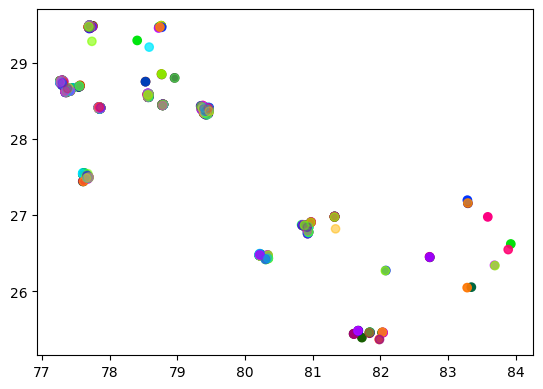

In [100]:
matched_rooftop_centroids_gdf.sample(1000).plot(
    cmap=ListedColormap(generate_colormap(len(matched_rooftop_centroids_gdf))),
)

## 7. Load matched rooftops

In [211]:
matched_rooftop_dir = CLEANED_DATA_DIR / "01. Matched Rooftop Data"
all_filepaths = list(matched_rooftop_dir.glob("**/*.parquet"))
all_filepaths = [f for f in all_filepaths if f.is_file()]

# load all shapes into one gdf
matched_rooftops_gdf_list = []
for filepath in tqdm(all_filepaths):
    matched_rooftops_gdf_list.append(gpd.read_parquet(filepath))
matched_rooftops_gdf = gpd.GeoDataFrame(
    pd.concat(matched_rooftops_gdf_list, ignore_index=True)
).to_crs(4326)

  0%|          | 0/7 [00:00<?, ?it/s]

In [212]:
len(matched_rooftops_gdf)

5222080

In [213]:
no_rooftop_PSU_IDs = set(combined_gdf["PSU_ID"].unique()).difference(set(matched_rooftops_gdf["PSU_ID"].unique()))
no_rooftop_PSU_gdf = combined_gdf[combined_gdf["PSU_ID"].isin(no_rooftop_PSU_IDs)]
no_rooftop_PSU_gdf

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,Urban/Rural,...,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,TV Code_MapSolve,TV Name,Ward Code_MapSolve,Total Population,geometry,PCA_ID_MapSolve,PSU_ID
180,10.0,Bihar,215.0,Darbhanga,1184.0,Darbhanga,227041.0,0.0,Belhar,Rural,...,Darbhanga,1184.0,Darbhanga,NaN,Belhar,NaN,2378.0,"POLYGON ((85.92565 26.18047, 85.92565 26.18023...",227041,TV_227041.0
182,10.0,Bihar,215.0,Darbhanga,1189.0,Bahadurpur,227303.0,0.0,Teunga,Rural,...,Darbhanga,1189.0,Bahadurpur,NaN,Teunga,NaN,1268.0,"MULTIPOLYGON (((85.82837 26.14152, 85.82837 26...",227303,TV_227303.0


In [214]:
no_rooftop_PSU_gdf.to_csv(
    OUTPUT_DATA_DIR / "Sampled PSUs" / "PSU_IDs_with_no_rooftops.csv",
    index=False,
)

## 8. Sample rooftops

### Filter to only IFS for now

In [215]:
matched_rooftops_gdf = matched_rooftops_gdf[matched_rooftops_gdf["Sampled for IFS"] == "Yes"]

In [216]:
matched_rooftops_gdf["PSU_ID"].nunique()

106

### Do the sampling

In [217]:
NUM_ROOFTOPS_PER_AREA = 25

In [221]:
sampled_rooftops = matched_rooftops_gdf.groupby(
    "PSU_ID", group_keys=False
).apply(lambda x: x.sample(n=min(NUM_ROOFTOPS_PER_AREA, x.shape[0]), random_state=42))

<Axes: >

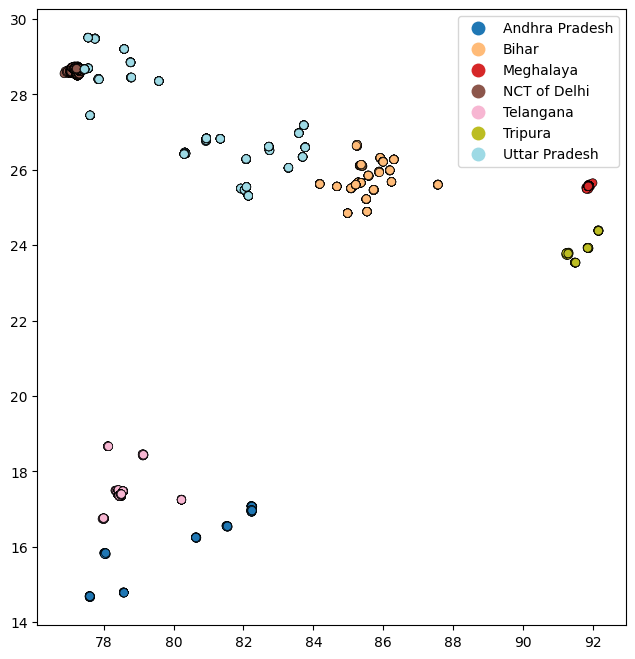

In [222]:
sampled_rooftops.plot(
    figsize=(8, 8),
    column="State Name",
    cmap="tab20",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
)

### Add sample-level rooftop numbering ID columns

In [223]:
# Rooftop number within each state
sampled_rooftops["Rooftop State ID"] = (
    sampled_rooftops.groupby("State Name").cumcount() + 1
)

# Rooftop number within each PSU_ID
sampled_rooftops["Rooftop PSU ID"] = sampled_rooftops.groupby("PSU_ID").cumcount() + 1

# Rooftop unique ID
sampled_rooftops["Rooftop Unique ID"] = sampled_rooftops.apply(
    lambda row: f"STATE_{row['Rooftop State ID']}_PSU_ID_{row['PSU_ID']}_ROOFTOP_{row['Rooftop PSU ID']}",
    axis=1,
)

### Add gmap link

In [224]:
sampled_rooftops["latitude"] = sampled_rooftops.geometry.y
sampled_rooftops["longitude"] = sampled_rooftops.geometry.x
sampled_rooftops["gmap_link"] = create_gmap_links(
    df=sampled_rooftops,
    lat_name="latitude",
    lon_name="longitude",
)

### Select only useful columns

**Required columns:**
- PSU info
    - Unique ID across all rooftops
    - Rooftop state ID, #
    - Rooftop PSU_ID, #

    - PSU Unit: Ward, TV, Subdistrict
    - PSU sample size

- geospatial info
    - google maps link
    - coordinates
    - geometry

- Admin location info
    - State code and name
    - District code and Name
    - Subdistrict code and name
    - TV code and name
    - Ward code and name

In [227]:
chosen_cols = [
    ## IDs
    "Rooftop State ID",
    "Rooftop PSU ID",
    "Rooftop Unique ID",

    ## Geospatial data
    "geometry",
    "latitude",
    "longitude",
    "gmap_link",

    ## PSU info
    "PSU_ID",
    "PSU Type",
    "Ward Count",

    ## Location info
    "State Code",
    "State Name",
    "State Changed",
    "District Code",
    "District Name",
    "Subdistrict Code",
    "Subdistrict Name",
    "TV Code",
    "TV Name",  # (from MapSolve)
    "Ward Code",
    "Ward/Village Name",
    "Urban/Rural",
    "PCA_ID",  # combined TVCode-WardCode
    "Ward Population",
    "Subdistrict Population",
    "State Population",
    # "Complete ID",

    ## Admin information
    # "Sampled for Panel",
    # "Sampled for IFS",
    "Ward Boundary Available with MapSolve",
    # "Source Sheet",
    # "State Shared by MapSolve",
    "Ward Boundary Given",
    "TV Boundary Given",
    "SubDistrict Boundary Given",
    "Delivery State",
    # "UID",
    # "s2_rooftop_id",

    ## MapSolve location info
    "State Code_MapSolve",
    "State Name_MapSolve",
    "District Code_MapSolve",
    "District Name_MapSolve",
    "Subdistrict Code_MapSolve",
    "Subdistrict Name_MapSolve",
    "TV Code_MapSolve",
    # "TV Name",
    "Ward Code_MapSolve",
    "PCA_ID_MapSolve",
    "Total Population",

    # ## rooftop info
    # "boundary_id",
    # "bf_source",
    # "confidence",
    # "area_in_meters",
    # "s2_id",
    # "country_iso",
    # "geohash",
    # "bbox",

]

In [228]:
sampled_rooftops_organised_gdf = sampled_rooftops[chosen_cols]

In [230]:
sampled_rooftops_organised_gdf.rename(
    columns={
        "TV Name": "TV Name_MapSolve",
        "PSU_ID" : "PSU ID",
        "Total Population": "PSU Total Population_MapSolve",
    },
    inplace=True,
)

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_41929/1139571638.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sampled_rooftops_organised_gdf.rename(


In [231]:
# set Ward Codes of 0.0 to NaN
sampled_rooftops_organised_gdf.loc[
    sampled_rooftops_organised_gdf["Ward Code"] == 0.0, "Ward Code"
] = np.nan

In [233]:
sampled_rooftops_organised_gdf

,Rooftop State ID,Rooftop PSU ID,Rooftop Unique ID,geometry,latitude,longitude,gmap_link,PSU ID,PSU Type,Ward Count,...,State Code_MapSolve,State Name_MapSolve,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,TV Code_MapSolve,Ward Code_MapSolve,PCA_ID_MapSolve,PSU Total Population_MapSolve
3506388,1,1,STATE_1_PSU_ID_SUBDISTRICT_1932.0_ROOFTOP_1,POINT (91.28675 23.79413),23.794130,91.286751,https://www.google.com/maps/search/?api=1&quer...,SUBDISTRICT_1932.0,subdistrict,2,...,16.0,Tripura,289.0,West Tripura,NaN,Dukli,NaN,NaN,272017,118886.0
3492062,2,2,STATE_2_PSU_ID_SUBDISTRICT_1932.0_ROOFTOP_2,POINT (91.25044 23.79581),23.795815,91.250444,https://www.google.com/maps/search/?api=1&quer...,SUBDISTRICT_1932.0,subdistrict,2,...,16.0,Tripura,289.0,West Tripura,NaN,Dukli,NaN,NaN,272017,118886.0
3466762,3,3,STATE_3_PSU_ID_SUBDISTRICT_1932.0_ROOFTOP_3,POINT (91.26670 23.73952),23.739516,91.266702,https://www.google.com/maps/search/?api=1&quer...,SUBDISTRICT_1932.0,subdistrict,2,...,16.0,Tripura,289.0,West Tripura,NaN,Dukli,NaN,NaN,272017,118886.0
3466180,4,4,STATE_4_PSU_ID_SUBDISTRICT_1932.0_ROOFTOP_4,POINT (91.27209 23.73571),23.735709,91.272092,https://www.google.com/maps/search/?api=1&quer...,SUBDISTRICT_1932.0,subdistrict,2,...,16.0,Tripura,289.0,West Tripura,NaN,Dukli,NaN,NaN,272017,118886.0
3508480,5,5,STATE_5_PSU_ID_SUBDISTRICT_1932.0_ROOFTOP_5,POINT (91.29644 23.78708),23.787079,91.296443,https://www.google.com/maps/search/?api=1&quer...,SUBDISTRICT_1932.0,subdistrict,2,...,16.0,Tripura,289.0,West Tripura,NaN,Dukli,NaN,NaN,272017,118886.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025026,346,21,STATE_346_PSU_ID_WARD_802918-81_ROOFTOP_21,POINT (78.49385 17.39185),17.391850,78.493847,https://www.google.com/maps/search/?api=1&quer...,WARD_802918-81,ward,1,...,28.0,Andhra Pradesh,536.0,Hyderabad,NaN,None,802918.0,81.0,None,30388.0
1023874,347,22,STATE_347_PSU_ID_WARD_802918-81_ROOFTOP_22,POINT (78.49783 17.38957),17.389572,78.497832,https://www.google.com/maps/search/?api=1&quer...,WARD_802918-81,ward,1,...,28.0,Andhra Pradesh,536.0,Hyderabad,NaN,None,802918.0,81.0,None,30388.0
1024629,348,23,STATE_348_PSU_ID_WARD_802918-81_ROOFTOP_23,POINT (78.49156 17.39397),17.393975,78.491556,https://www.google.com/maps/search/?api=1&quer...,WARD_802918-81,ward,1,...,28.0,Andhra Pradesh,536.0,Hyderabad,NaN,None,802918.0,81.0,None,30388.0
1026328,349,24,STATE_349_PSU_ID_WARD_802918-81_ROOFTOP_24,POINT (78.50041 17.39272),17.392722,78.500409,https://www.google.com/maps/search/?api=1&quer...,WARD_802918-81,ward,1,...,28.0,Andhra Pradesh,536.0,Hyderabad,NaN,None,802918.0,81.0,None,30388.0


### Save sampled data (original rooftop pins)

In [234]:
save_shapefiles(
    sampled_rooftops_organised_gdf,
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_original_centroids",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Lossy conversion occurred when trying to set 64 bit integer field from a real value.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=23.794129775050287,91.28675077072354' of field sampled_rooftops_original_centroids.latitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'SUBDISTRICT_1932.0' of field sampled_rooftops_original_centroids.longitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field sampled_rooftops_original_centroids.State Code parsed incompletely to real 0.
  o

## 9. Snap points to road

In [236]:
sampled_rooftops_organised_gdf["PSU ID"].nunique()

106

## Scraps

In [ ]:
# def create_grid_points(gdf, cell_size=0.05) -> gpd.GeoDataFrame:
#     """
#     Create a grid of points within the bounds of the unary geometry of the GeoDataFrame.

#     Parameters:
#     - gdf: GeoDataFrame
#     - cell_size: float, size of the grid cells

#     Returns:
#     - GeoDataFrame with grid points
#     """

#     bounds = gdf.unary_union.bounds
#     min_lon, min_lat, max_lon, max_lat = bounds

#     # Create a grid of points
#     lons = np.arange(min_lon, max_lon, cell_size)
#     lats = np.arange(min_lat, max_lat, cell_size)
#     lon_grid, lat_grid = np.meshgrid(lons, lats)

#     # Flatten the grid and create a GeoDataFrame
#     points = gpd.GeoDataFrame(
#         geometry=gpd.points_from_xy(lon_grid.flatten(), lat_grid.flatten()),
#         crs="EPSG:4326",
#     )

#     # Filter points that are within the unary geometry
#     points = points[points.geometry.within(gdf.unary_union)]

#     return points

In [ ]:
# import os
# import concurrent.futures
# from concurrent.futures import ThreadPoolExecutor

# def download_VIDA_rooftops_data_by_s2(
#     s2_cell_ids: list[int], country_iso_code: str, target_data_dir: Path, n_jobs: int = -1
# ) -> None:
#     """
#     Download S2 rooftops data for multiple S2 cell IDs in parallel.

#     Args:
#         s2_cell_ids: List of S2 cell IDs to download data for
#         country_iso_code: ISO code for the country (e.g. "IND", "PHL")
#         target_data_dir: Directory to save downloaded files
#         n_jobs: Number of concurrent downloads. If -1, uses all available cores.
#     """

#     if not isinstance(n_jobs, int) or n_jobs < -1 or n_jobs == 0:
#         raise ValueError("n_jobs must be -1 or a positive integer.")

#     if n_jobs == -1:
#         n_jobs = os.cpu_count() or 1  # 1 in case os.cpu_count() returns None

#     print(f"Downloading rooftops data for {len(s2_cell_ids)} S2 cell IDs in parallel using {n_jobs} jobs.")

#     # Track errors
#     error_count = 0
#     errors = {}

#     # Define a wrapper function to handle exceptions
#     def download_with_error_handling(s2_cell_id, country_iso_code, target_data_dir):
#         try:
#             download_VIDA_rooftops_data_by_s2_single(s2_cell_id, country_iso_code, target_data_dir)
#             return s2_cell_id, None
#         except Exception as e:
#             return s2_cell_id, str(e)

#     # Use ThreadPoolExecutor for I/O bound operations
#     with ThreadPoolExecutor(max_workers=n_jobs) as executor:
#         futures = [
#             executor.submit(
#                 download_with_error_handling, s2_cell_id, country_iso_code, target_data_dir
#             )
#             for s2_cell_id in s2_cell_ids
#         ]

#         # Show progress with tqdm
#         progress_bar = tqdm(
#             total=len(futures),
#             desc="Downloading rooftops data"
#         )

#         for future in concurrent.futures.as_completed(futures):
#             s2_cell_id, error = future.result()

#             if error:
#                 error_count += 1
#                 errors[s2_cell_id] = error
#                 progress_bar.set_description(f"Downloading rooftops data (errors: {error_count})")

#             progress_bar.update(1)

#         progress_bar.close()

#     # Print summary of errors
#     if errors:
#         print(f"\n⚠️ {error_count} errors occurred during download:")
#         for s2_cell_id, error in errors.items():
#             print(f"  - S2 cell {s2_cell_id}: {error}")
#         print(f"{len(s2_cell_ids) - error_count} of {len(s2_cell_ids)} files downloaded successfully.")
#     else:
#         print(f"\n✅ All {len(s2_cell_ids)} files downloaded successfully.")

In [ ]:
sample_df

In [ ]:
sample_df[sample_df["State_Name"] == "NCT OF DELHI"]